In [1]:
%reload_ext autoreload
%autoreload 2
import sys

sys.path.append("../../..")

In [2]:
import pandas as pd

from tqdm import tqdm
from pathlib import Path

from ltr_utility.dataset import load_query_similarity, load_by_query_dataset, DatasetName
from ltr_utility.model_selection import evaluate, show_distr_conf, custom_train

from experiments.wrappers import *

In [3]:
base_path = Path("../../../datasets")
base_result = Path("results")
base_result.mkdir(parents=True, exist_ok=True)

In [4]:
eval_at = [1, 2, 3, 4, 6, 8, 10, 12, 15, 20, 25]
hold_out = (0.5, 0.2, 0.3)
iqr_trim = None  #(25, 75)
query_groups = load_query_similarity(Path("results"))

In [5]:
train, valid, test, train_valid = load_by_query_dataset(base_path, DatasetName.YAHOO, hold_out=hold_out)

Loading train dataset from cache.
Train data loaded from cache.
Loading valid dataset from cache.
Valid data loaded from cache.
Loading test dataset from cache.
Test data loaded from cache.
---- YAHOO loaded ----
Filtered out 358 queries with fewer than 10 documents.
---- discard_minority_groups 10 queries ----
---- Get first 500 queries ----
---- max_item 400 -(determistic!) ----
---- Holdout (0.5, 0.2, 0.3) - (determistic!) ----


# LambdaMART

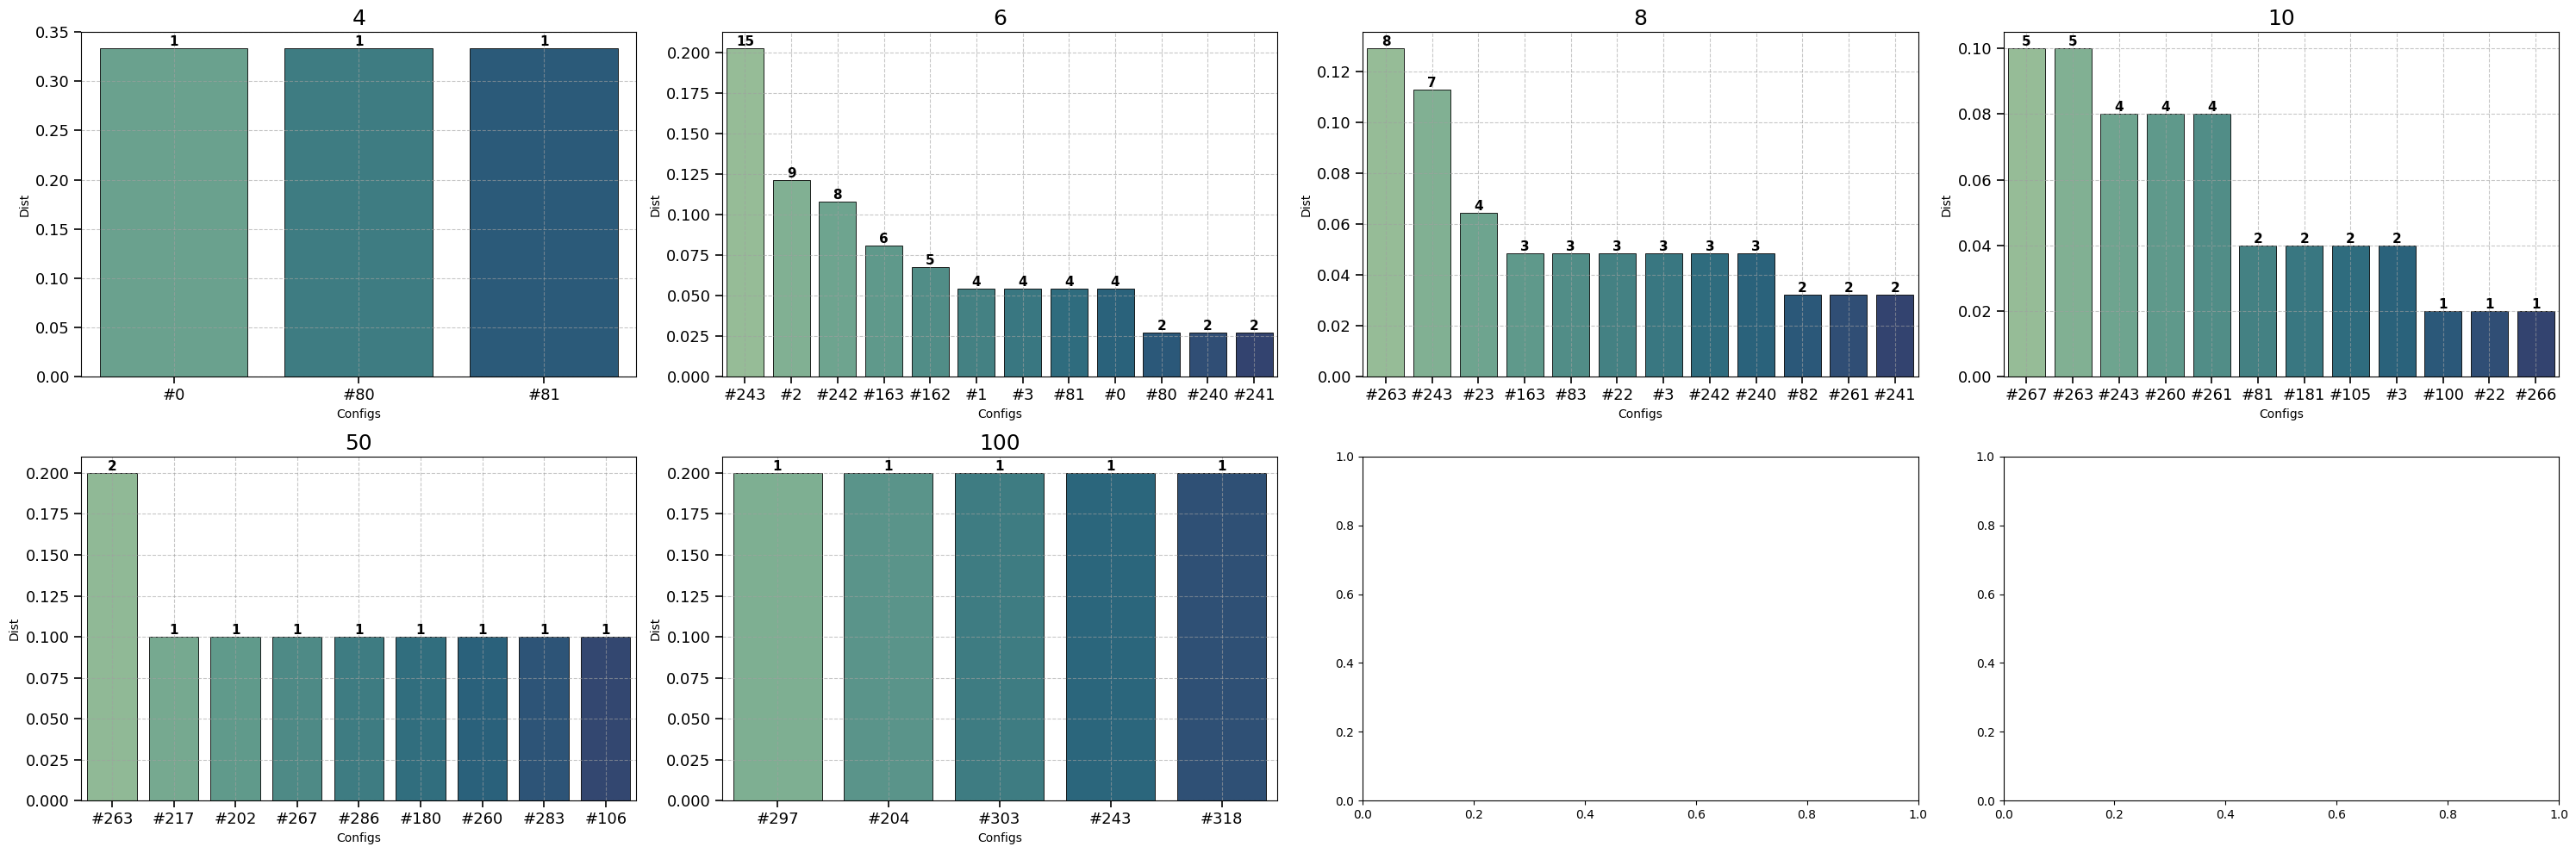

In [6]:
lm_ms = pd.read_json(base_result / "lm_query_model_selection.json")
lm_conf_dist = show_distr_conf(lm_ms)

In [14]:
lm_result = custom_train(
    base_result,
    train_valid,
    test,
    {4:0, 6:243, 8:263, 10:267, 50:263, 100:297},
    "lm_query_model_selection.json",
    lm_ms,
    "LambdaMART",
    WrapperLGBMRanker
)

Training with one-shot mode (dict params).


Training: 100%|██████████| 125/125 [00:01<00:00, 70.38it/s]


Training with one-shot mode (dict params).


Training: 100%|██████████| 84/84 [00:03<00:00, 23.70it/s]


Training with one-shot mode (dict params).


...

Training: 100%|██████████| 50/50 [00:05<00:00,  8.67it/s]


Training with one-shot mode (dict params).


Training: 100%|██████████| 10/10 [00:02<00:00,  3.51it/s]


Training with one-shot mode (dict params).


Training: 100%|██████████| 5/5 [00:00<00:00,  6.38it/s]


# KNN

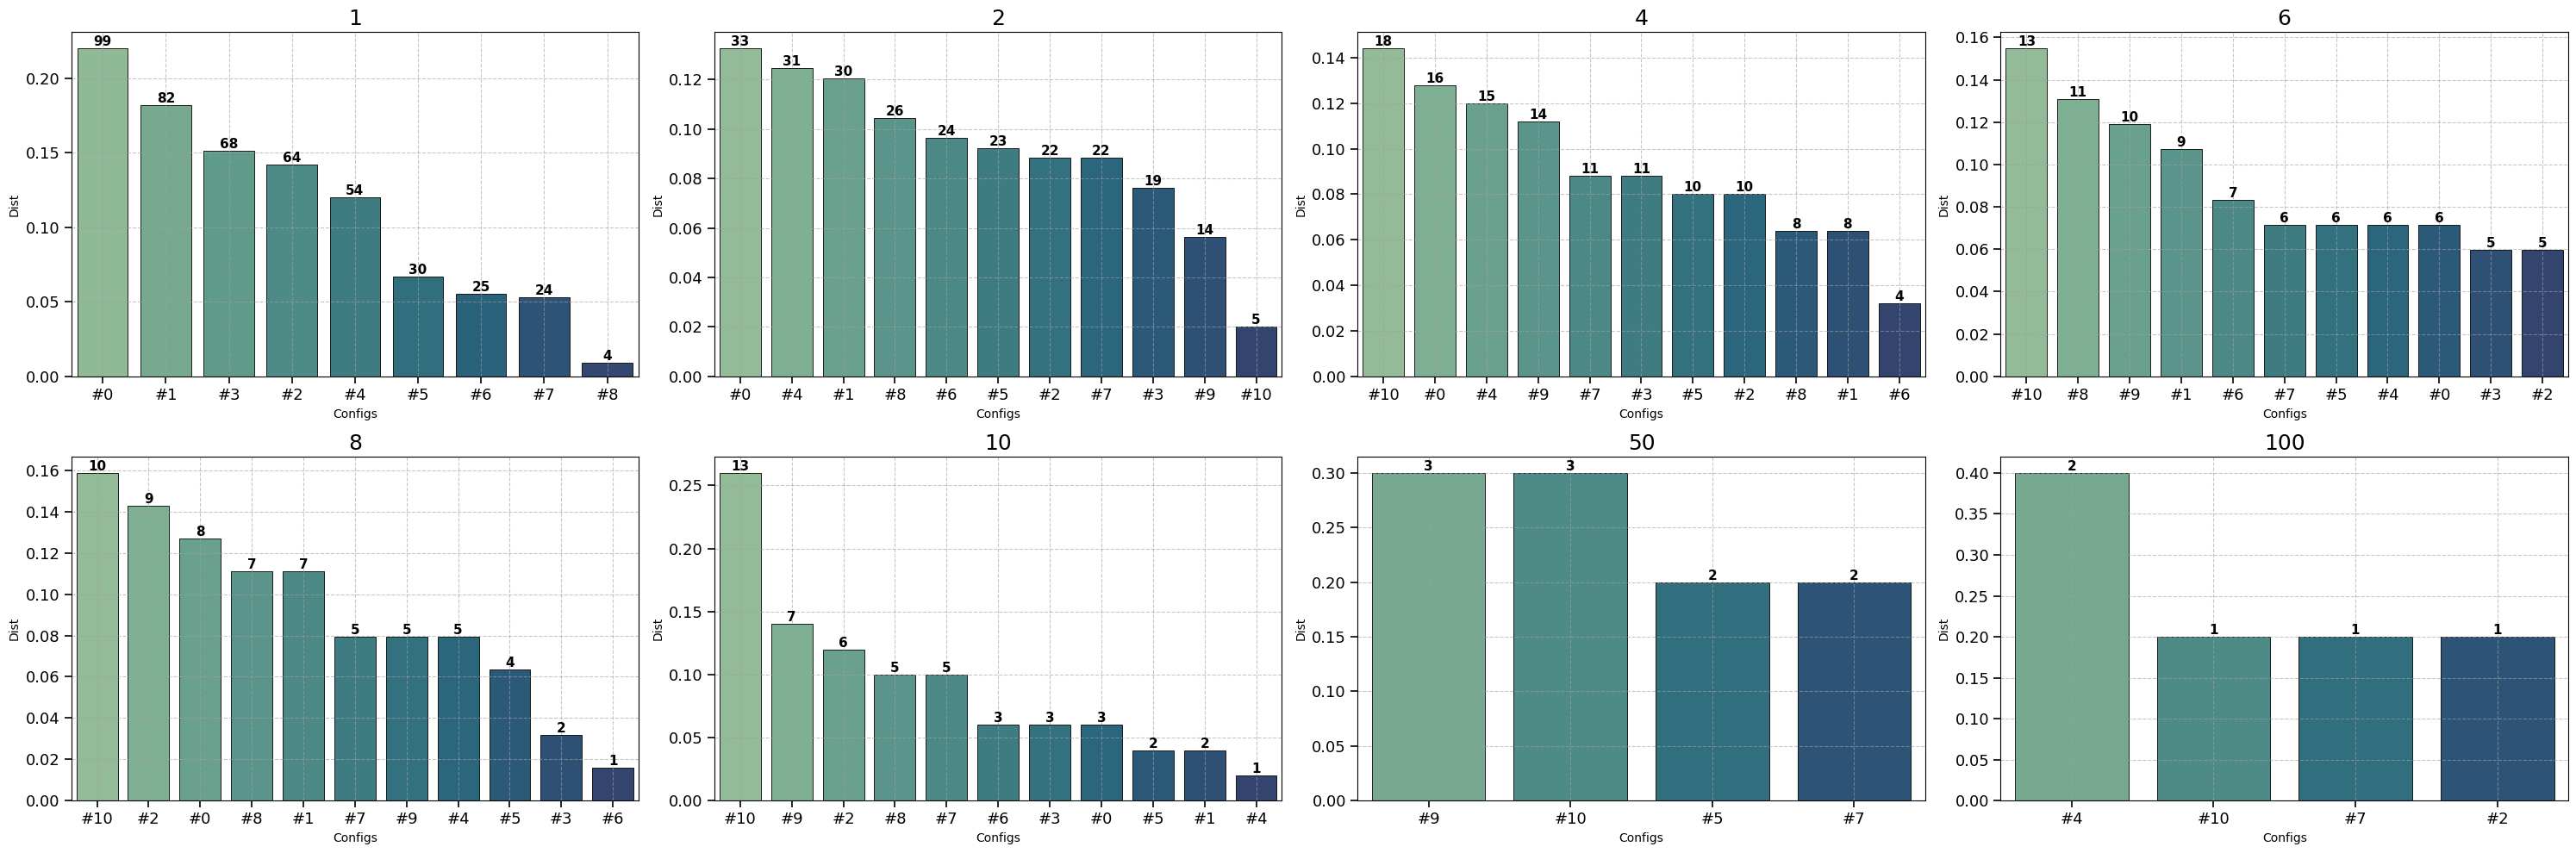

In [7]:
knn_ms = pd.read_json(base_result / "knn_query_model_selection.json")
knn_conf_dist = show_distr_conf(knn_ms)

In [15]:
knn_result = custom_train(
    base_result,
    train_valid,
    test,
    {1:0, 2:0, 4:10, 6:10, 8:10 , 10:10, 50:9, 100:4},
    "knn_query_model_selection.json",
    knn_ms,
    "KNN Regressor",
    WrapperKNN
)

Training with one-shot mode (dict params).


Training: 100%|██████████| 500/500 [00:00<00:00, 4191.24it/s]


Training with one-shot mode (dict params).


Training: 100%|██████████| 250/250 [00:00<00:00, 3300.91it/s]


Training with one-shot mode (dict params).


...

Training: 100%|██████████| 50/50 [00:00<00:00, 1828.87it/s]


Training with one-shot mode (dict params).


Training: 100%|██████████| 10/10 [00:00<00:00, 712.76it/s]


Training with one-shot mode (dict params).


Training: 100%|██████████| 5/5 [00:00<00:00, 285.21it/s]


# RuleTreeRank

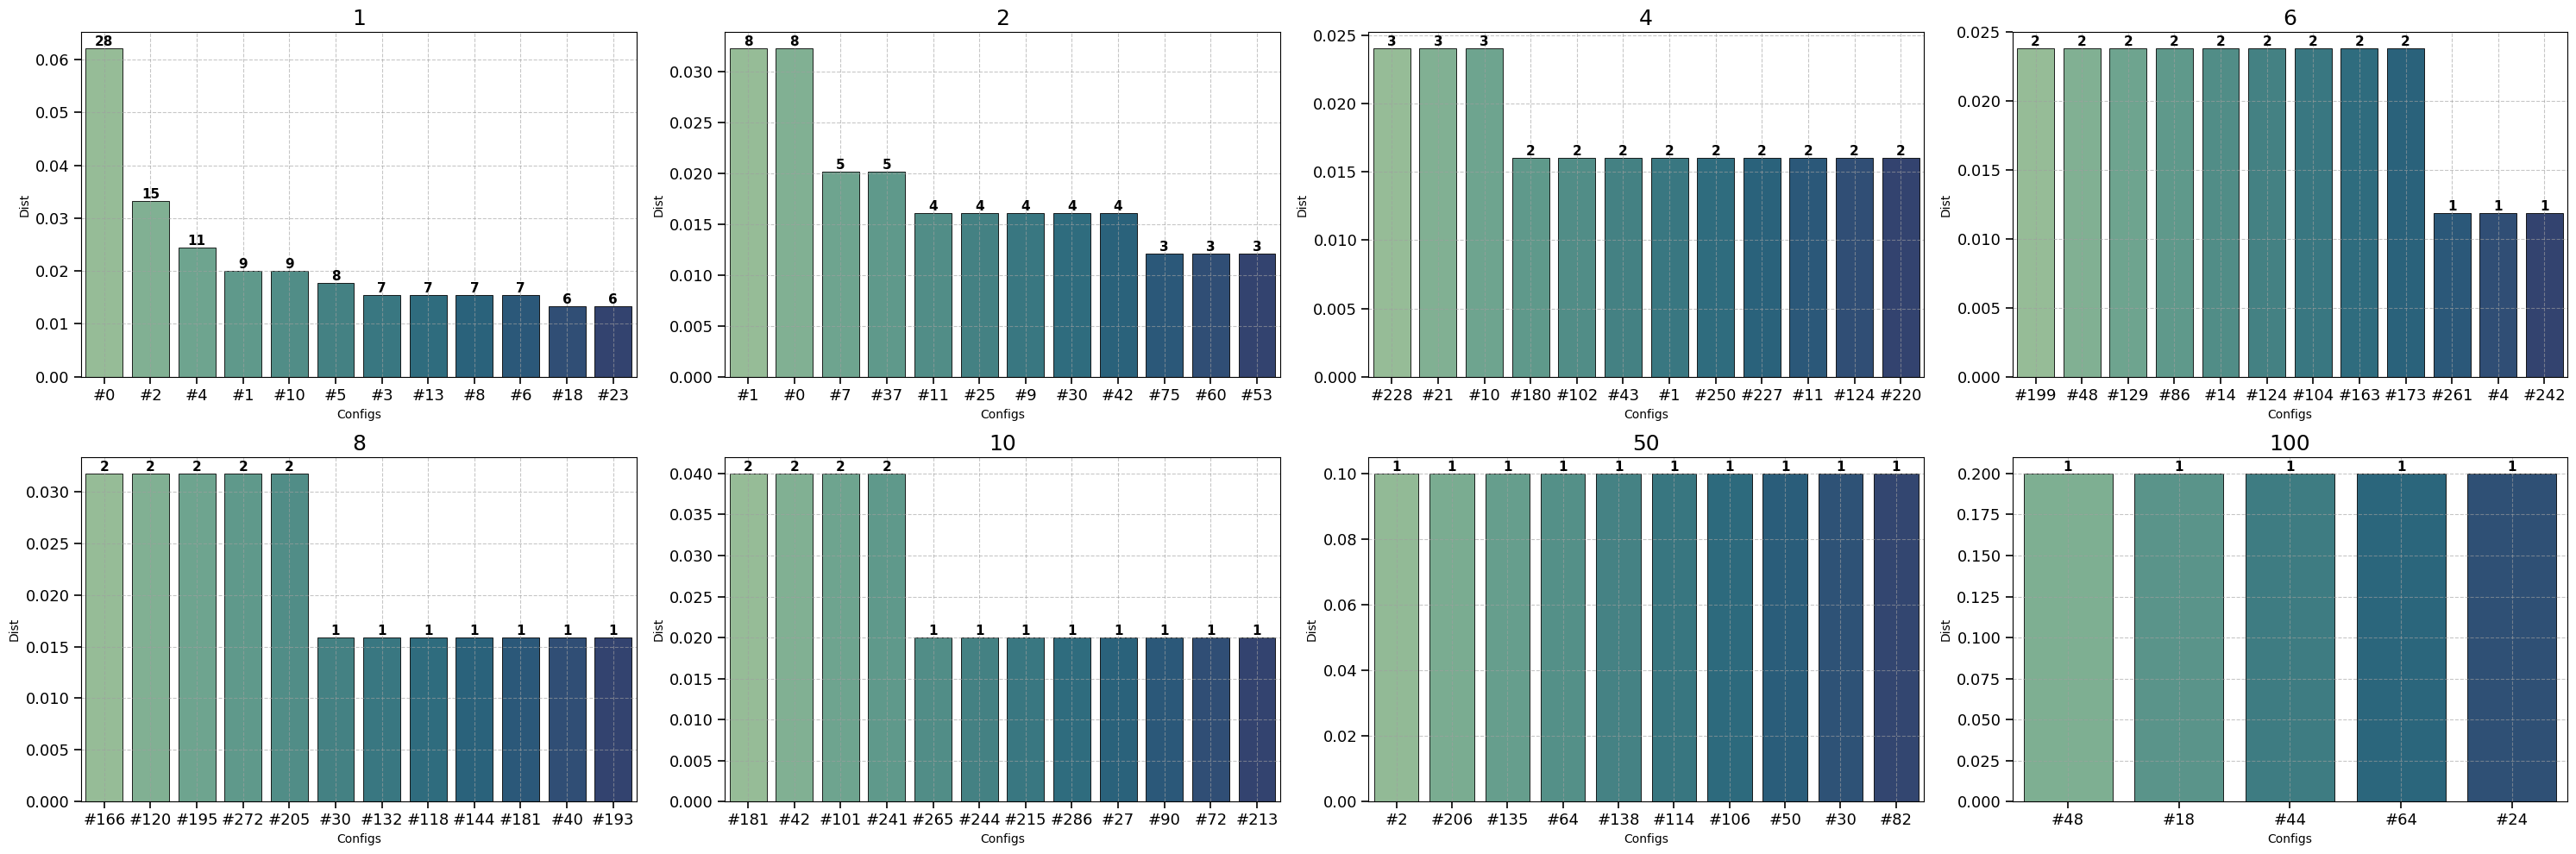

In [8]:
rtr_ms = pd.read_json(base_result / "rtr_query_model_selection.json")
rtr_conf_dist = show_distr_conf(rtr_ms)

In [16]:
rtr_result = custom_train(
    base_result,
    train_valid,
    test,
    {1:0, 2:1, 4:228, 6:199, 8:166, 10:181, 50:2, 100:48},
    "rtr_query_model_selection.json",
    rtr_ms,
    "RuleTreeRank",
    WrapperRTR,
    rtr=True
)

1
Training with one-shot mode (dict params).


Training: 100%|██████████| 500/500 [00:33<00:00, 14.72it/s]


Eval
2
Training with one-shot mode (dict params).


Training: 100%|██████████| 125/125 [00:14<00:00,  8.40it/s]


Eval
6
Training with one-shot mode (dict params).


...

Eval
50
Training with one-shot mode (dict params).


Training: 100%|██████████| 10/10 [00:53<00:00,  5.37s/it]


Eval
100
Training with one-shot mode (dict params).


Training: 100%|██████████| 5/5 [11:49<00:00, 141.84s/it]


Eval


# Mixed RuleTreeRank

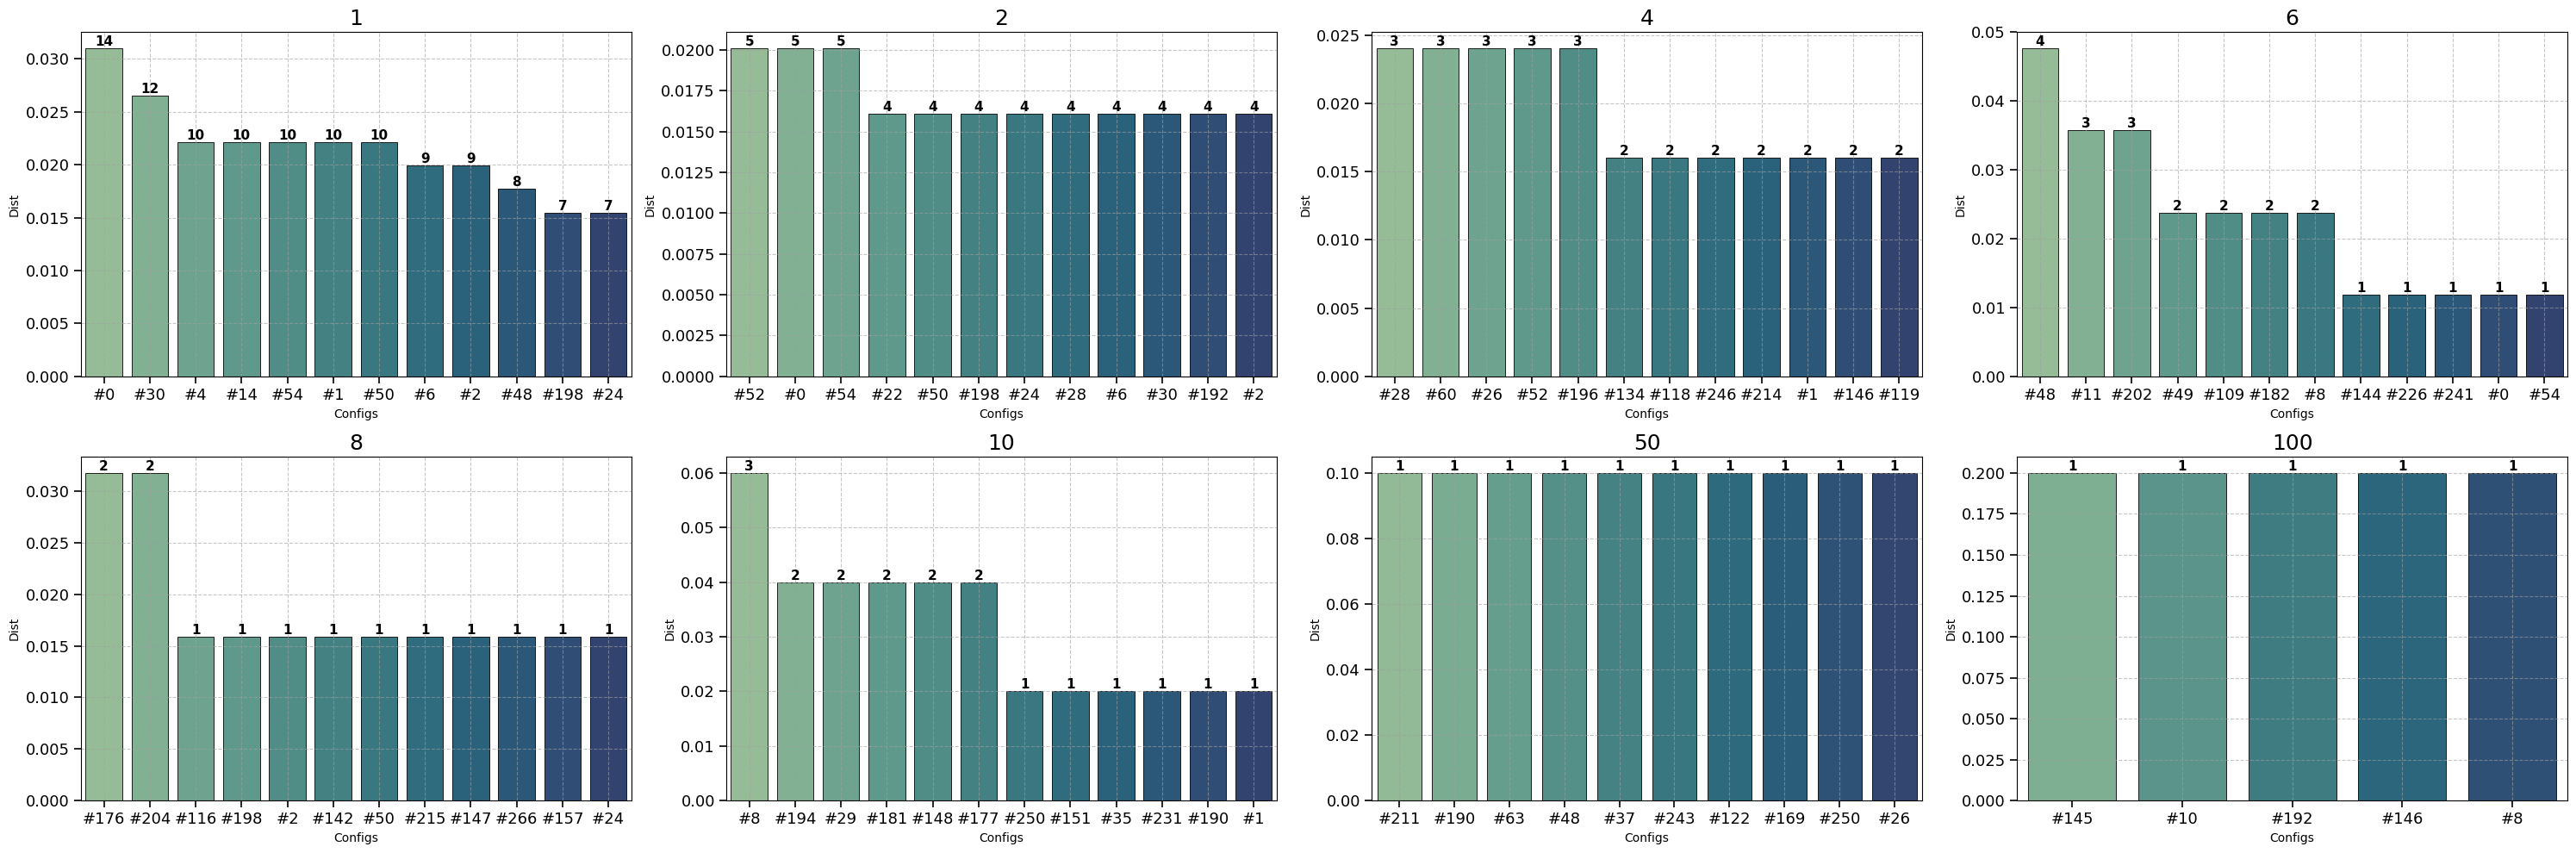

In [6]:
mix_rtr_ms = pd.read_json(base_result / "mix_rtr_query_model_selection.json")
mix_rtr_conf_dist = show_distr_conf(mix_rtr_ms)

In [7]:
mix_rtr_result = custom_train(
    base_result,
    train_valid,
    test,
    {1:0, 2:52, 4:28, 6:48, 8:176, 10:8, 50:221, 100:145},
    "mix_rtr_query_model_selection.json",
    mix_rtr_ms,
    "Mix-RuleTreeRank",
    WrapperMixRTR,
    rtr=True
)

1
Training with one-shot mode (dict params).


Training: 100%|██████████| 500/500 [00:27<00:00, 17.89it/s]


Eval
2
Training with one-shot mode (dict params).


Training: 100%|██████████| 250/250 [00:23<00:00, 10.65it/s]


Eval
4
Training with one-shot mode (dict params).


...

Eval
50
Training with one-shot mode (dict params).


Training: 100%|██████████| 10/10 [00:09<00:00,  1.04it/s]


Eval
100
Training with one-shot mode (dict params).


Training: 100%|██████████| 5/5 [00:02<00:00,  1.95it/s]


Eval


# KNN PDT

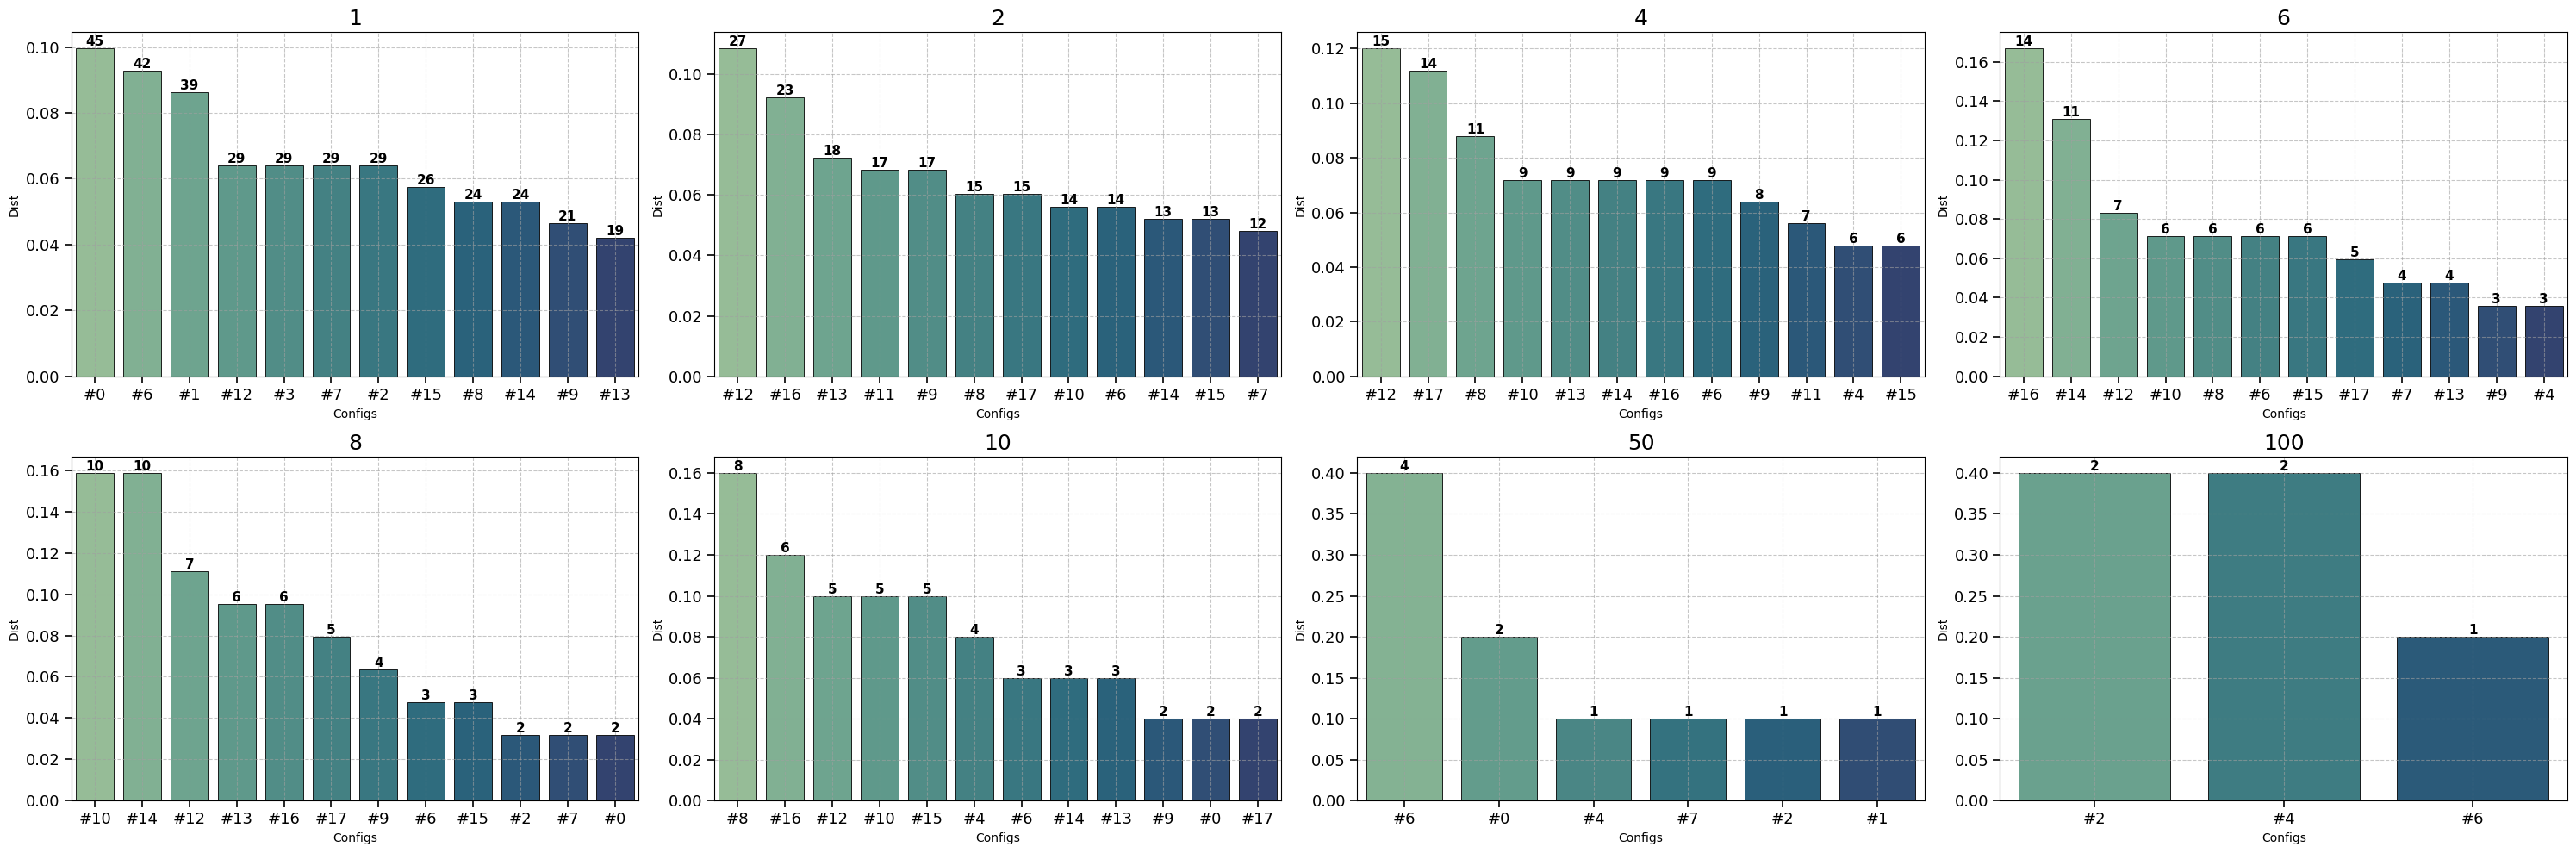

In [8]:
knn_pdt_ms = pd.read_json(base_result / "knn_pdt_query_model_selection.json")
knn_pdt_conf_dist = show_distr_conf(knn_pdt_ms)

In [9]:
knn_pdt_result = custom_train(
    base_result,
    train_valid,
    test,
    {1:0, 2:12, 4:12, 6:16, 8:10, 10:8, 50:6, 100:2},
    "knn_pdt_query_model_selection.json",
    knn_pdt_ms,
    "KNNwPDT",
    WrapperKNNPDT,
    rtr=True
)

1
Training with one-shot mode (dict params).


Training: 100%|██████████| 500/500 [00:05<00:00, 84.36it/s]


Eval
2
Training with one-shot mode (dict params).


Training: 100%|██████████| 250/250 [00:27<00:00,  8.98it/s]


Eval
4
Training with one-shot mode (dict params).


...

Eval
50
Training with one-shot mode (dict params).


Training: 100%|██████████| 10/10 [07:41<00:00, 46.19s/it]


Eval
100
Training with one-shot mode (dict params).


Training: 100%|██████████| 5/5 [12:04<00:00, 144.83s/it]


Eval


In [22]:
from ltr_utility.model_selection.retrain import retrain_evaluate

random_result = retrain_evaluate(
    train_valid=train_valid,
    test=test,
    configs={i: (None, {}) for i in [1, 2, 4, 6, 8, 10, 50, 100]},
    model=RandomRanker, name="RandomRanker")

Training with one-shot mode (dict params).


Training: 100%|██████████| 500/500 [00:00<00:00, 17372.03it/s]


Training with one-shot mode (dict params).


Training: 100%|██████████| 250/250 [00:00<00:00, 15603.58it/s]


Training with one-shot mode (dict params).


...

Training: 100%|██████████| 50/50 [00:00<00:00, 8943.84it/s]


Training with one-shot mode (dict params).


Training: 100%|██████████| 10/10 [00:00<00:00, 1218.50it/s]


Training with one-shot mode (dict params).


Training: 100%|██████████| 5/5 [00:00<00:00, 987.03it/s]


# Evalutate results

In [ ]:
df_result = pd.concat([
    knn_pdt_result,
    knn_result,
    lm_result,
    mix_rtr_result,
    rtr_result,
    random_result,
], axis=0)


In [24]:
pd.concat([
    results,
    pd.read_json(base_result / "ilmart_query_model_selection.json"),
    pd.read_json(base_result / "listnet_query_model_selection.json"),
], axis=0).to_json(base_result / "YAHOO_result.json", orient="records")

In [6]:
# pd.concat([
#     pd.read_json(base_result / "YAHOO_result.json"),
#     pd.read_json(base_result / "listnet_query_model_selection.json"),
# ], axis=0).to_json(base_result / "YAHOO_result.json", orient="records")

In [10]:
# Results for boxplot
# results = []
# df_result = pd.concat([mix_rtr_result, knn_pdt_result], axis=0)
# for _, row in tqdm(df_result.iterrows(), total=len(mix_rtr_result)):
#     for k in eval_at:
#         res = evaluate(row["pred_test"], test.y, test.group_count, k=k,
#                        weight=False, aggregated=False)
#         results.append((row["model"], "test", row["qxm"], k, res))
#
# results = pd.DataFrame(results, columns=["model", "fold", "qxm", "k", "ndcg_s"])
# results.to_csv("YAHOO_noagg.csv")

48it [01:10,  1.48s/it]                        
